# Universidad de Buenos Aires
# Aprendizaje Profundo - TP3
# Cohorte 22 - 5to bimestre 2025


Este tercer y último TP se debe entregar hasta las **23hs del viernes 12 de diciembre (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar los contenidos vistos en clase y otra bibliografía. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP3 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/kscHDArwzdvrTSG99)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP3.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP3-Co22.ipynb**
- Los códigos deben poder ejecutarse.
- Los resultados, cómo el código, los gráficos y las explicaciones deben quedar guardados y visualizables en el correspondiente notebook.
- Prestar atención a las consignas, responder las preguntas cuando corresponda.
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# **CLASIFICADOR DE EMOCIONES**

El objetivo de este trabajo es construir una red neuronal convolucional (CNN) utilizando Pytorch, capaz de clasificar emociones humanas a partir de imágenes faciales. El clasificador deberá identificar una de las 7 emociones básicas: alegría, tristeza, enojo, miedo, sorpresa, disgusto y seriedad. El dataset se encuentra en este link: https://drive.google.com/file/d/1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT/view?usp=sharing

Les recomiendo usar el siguiente código para poder obtener las imágenes fácilmente desde ese link. Pero son libres de descargar las imágenes como mejor les parezca.

In [17]:
import gdown
import zipfile
import os

url = "https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT"
output = "archivo.zip"

gdown.download(url, output, quiet=False)

destino = "datos_zip"
os.makedirs(destino, exist_ok=True)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(destino)

DATASET_ROOT_TRAIN = '/content/datos_zip/dataset_emociones/train'
DATASET_ROOT_VAL   = '/content/datos_zip/dataset_emociones/validation'


Downloading...
From (original): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT
From (redirected): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT&confirm=t&uuid=f8590669-2abf-45bf-be7a-ecce2d1c86f7
To: /home/jiteich/repos/ceia/deeplearning/TP3/archivo.zip
100%|██████████| 40.0M/40.0M [00:01<00:00, 22.8MB/s]


## 1. Preprocesamiento de Datos (2 puntos)

Antes de entrenar el modelo, se debe analizar qué tipo de preprocesamiento se debe aplicar a las imágenes. Para esto, se puede considerar uno o más aspectos como:

- Tamaño
- Relación de aspecto
- Color o escala de grises
- Cambio de dimensionalidad
- Normalización
- Balanceo de datos
- Data augmentation
- etc.

Sean criteriosos y elijan solo las técnicas que consideren pertinentes para este caso de uso en específico.

Recomendación: usar `torchvision.transforms` para facilitar el preprocesamiento. Lean su documentación si tienen dudas: https://docs.pytorch.org/vision/0.14/transforms.html



In [18]:
import matplotlib.pyplot as plt
import torchvision
import torch
from torchvision import transforms
import numpy as np
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import pandas as pd

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


Definimos la transformación de las imagenes de la siguiente manera:
- Aplicamos un `CenterCrop` para tomar un cuadrado de 100x100.
- Aplicamos un `Resize` a 100x100, meramente para asegurarnos que en caso de tener de input una imagen con dimension <100x100, no se tengan problemas de dimension.
- Llegamos la imagen a un tensor de `pytorch` con `ToTensor`.
- Normalizamos el tensor con media 0 y desvío estándar 1.

In [47]:
mean = 0
std = 1

composition = transforms.Compose([
    transforms.CenterCrop(size=100),
    transforms.Resize(size=100),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

Definimos el dataloader de train y de test con un batchsize de 64 para el train.
El batch size de test se pone en 3068 que son todos los valores de test que se tienen, de forma que sea sencilla la forma de evaluación del dataset de test completo.

In [ ]:
batch_size = 64
dataloader = {
    'train' : torch.utils.data.DataLoader(torchvision.datasets.ImageFolder(root='datos_zip/dataset_emociones/train/', transform=composition), batch_size=batch_size, shuffle=True, pin_memory=True),
    'test' : torch.utils.data.DataLoader(torchvision.datasets.ImageFolder(root='datos_zip/dataset_emociones/validation/', transform=composition), batch_size=3068, shuffle=True, pin_memory=True)
}

## 2. Construcción y entrenamiento del Modelo CNN (3.5 puntos)

- Construir una red neuronal convolucional desde cero, sin usar modelos pre-entrenados.
- Analizar correctamente qué funciones de activación se deben usar en cada etapa de la red, el learning rate a utilizar, la función de costo y el optimizador.
- Cosas como el número de capas, neuronas, número y tamaño de los kernels, entre otros, queda a criterio de ustedes, pero deben estar justificadas.

Definimos el bloque base de nuestra red convolucional `conv_block`, el cual consiste de:
- 1 capa convolucional `Conv2d`.
- 1 capa de activación `LeakyReLU`.
- 1 capa de pooling `MaxPool2d`.

Se realizaron pruebas con función de activación `Tanh`, pero se obtuvieron mejores resultados con `LeakyReLU`.

In [50]:
def conv_block(i, c_in, c_out, k=3, p='same', s=1, pk=2):        
    return [                               # el módulo Sequential se engarga de hacer el forward de todo lo que tiene dentro.
        (f'conv_{i}', torch.nn.Conv2d(c_in, c_out, k, padding=k//2, stride=s)), # conv
        # (f'act_{i}', torch.nn.Tanh()),                                      # activation
        (f'act_{i}', torch.nn.LeakyReLU()),                                      # activation
        (f'pool_{i}', torch.nn.MaxPool2d(pk))                             # pooling
    ]

Ahora definimos la red en si misma, de forma que sea escalable sencillamente a mayores y más densas capas según necesite el usuario. Se ponen las siguientes capas después de los bloques convolucionales para tener el bloque fully connected:
- 1 capa de `Flatten`.
- 1 capa de `Dropout`.
- 1 capa `Linear`.

Además a la salida de cada bloque convolucional se pone una capa de `Dropout` (a excepción de la última capa).

In [51]:
from collections import OrderedDict
class Flatten(torch.nn.Module):
    def forward(self, X):
        return X.flatten(start_dim=1)

class CNN(torch.nn.Module):
    def __init__(self, device, img_size, layers=2, in_channels=3, n_outputs=7, ch_per_layer=4, kernel_size=2, pool_kernel_size=2):
        super().__init__()

        # Define the architecture of the CNN
        self.layers = []
        in_feats = img_size # keep track of the input size of the fully connected layer
        for i in range(layers):
            # Convolutional Layer
            self.layers += conv_block(
                i = i,
                c_in = in_channels if i==0 else ch_per_layer,
                c_out=ch_per_layer if i==0 else ch_per_layer * 2, 
                k=kernel_size, 
                pk=pool_kernel_size,
                p=1
                )
            # Dropout Layer
            if i != layers - 1:
                self.layers.append((f'drop_{i}', torch.nn.Dropout2d(p=0.1, inplace=False)))

            # x2 channel amount
            if i > 0:
                ch_per_layer *= 2

            in_feats = 1 + int((in_feats + 2*0 - 1 * (pool_kernel_size-1))/pool_kernel_size)
        # Fully conected Layer
        in_feats = in_feats**2 * ch_per_layer
        self.layers.append(('flatten', Flatten()))
        self.layers.append(('drop', torch.nn.Dropout(p=0.1)))
        self.layers.append(('fully_connected', torch.nn.Linear(
            # in_features=(img_size * img_size / (pool_kernel_size * layers)), 
            in_features=in_feats, 
            out_features=n_outputs
            )))
        self.network = torch.nn.Sequential(
            OrderedDict(self.layers)
        ).to(device)

        print('----------------------------------------------')
        print('Red creada:')
        print(self.network)
        print('----------------------------------------------')
    
    def forward(self, X):
        y = self.network(X)
        return y

Probemos armar una red con hiperparámetros cualquiera:

In [52]:
model = CNN(device=device, img_size=100, in_channels=3, layers=3, ch_per_layer=4, kernel_size=4, pool_kernel_size=2)

----------------------------------------------
Red creada:
Sequential(
  (conv_0): Conv2d(3, 4, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
  (act_0): LeakyReLU(negative_slope=0.01)
  (pool_0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop_0): Dropout2d(p=0.1, inplace=False)
  (conv_1): Conv2d(4, 8, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
  (act_1): LeakyReLU(negative_slope=0.01)
  (pool_1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop_1): Dropout2d(p=0.1, inplace=False)
  (conv_2): Conv2d(8, 16, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
  (act_2): LeakyReLU(negative_slope=0.01)
  (pool_2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten()
  (drop): Dropout(p=0.1, inplace=False)
  (fully_connected): Linear(in_features=2704, out_features=7, bias=True)
)
----------------------------------------------


In [53]:
import torchinfo as torchinfo

torchinfo.summary(model, input_size=[1,3,100,100])

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [1, 7]                    --
├─Sequential: 1-1                        [1, 7]                    --
│    └─Conv2d: 2-1                       [1, 4, 101, 101]          196
│    └─LeakyReLU: 2-2                    [1, 4, 101, 101]          --
│    └─MaxPool2d: 2-3                    [1, 4, 50, 50]            --
│    └─Dropout2d: 2-4                    [1, 4, 50, 50]            --
│    └─Conv2d: 2-5                       [1, 8, 51, 51]            520
│    └─LeakyReLU: 2-6                    [1, 8, 51, 51]            --
│    └─MaxPool2d: 2-7                    [1, 8, 25, 25]            --
│    └─Dropout2d: 2-8                    [1, 8, 25, 25]            --
│    └─Conv2d: 2-9                       [1, 16, 26, 26]           2,064
│    └─LeakyReLU: 2-10                   [1, 16, 26, 26]           --
│    └─MaxPool2d: 2-11                   [1, 16, 13, 13]           --
│    └─Fla

Definimos ahora funciones para entrenar y testear el modelo:

In [54]:
def train_model(model, train_dataloader, test_dataloader, epochs, optimizer, loss):
    loss_evol = []
    ac_evol = []
    recall_evol = []
    f1_evol = []
    loss_test_evol = []
    ac_test_evol = []
    recall_test_evol = []
    f1_test_evol = []
    for epoch in range(epochs):
        model.train()
        epoch_loss = []
        epoch_recall = []
        epoch_f1 = []
        corrects = 0
        samples = 0
        for x_i, y_i in train_dataloader:
            x_i, y_i = x_i.to(device), y_i.to(device)
            yhat = model(x_i)
            loss_i = loss(yhat, y_i)
            optimizer.zero_grad(set_to_none=True)
            loss_i.backward()
            optimizer.step()

            epoch_loss.append(loss_i.item())

            preds_classes = yhat.argmax(dim=1)
            epoch_recall.append(recall_score(y_i.cpu(), preds_classes.cpu(), average='weighted', zero_division=np.nan))
            epoch_f1.append(f1_score(y_i.cpu(), preds_classes.cpu(), average='weighted'))
            corrects += (preds_classes == y_i).sum().item()
            samples += y_i.size(0)

        loss_evol.append(np.mean(epoch_loss))
        ac_evol.append(corrects/samples)
        recall_evol.append(np.mean(epoch_recall))
        f1_evol.append(np.mean(epoch_f1))

        test_loss, test_ac, test_recall, test_f1 = test_model(model, test_dataloader, loss)
        loss_test_evol.append(test_loss)
        ac_test_evol.append(test_ac)
        recall_test_evol.append(test_recall)
        f1_test_evol.append(test_f1)

        print(f'Epoch {epoch}:')
        print(f' Train Loss = {np.mean(epoch_loss):.4f}')
        print(f' Train Accuracy = {100 * corrects/samples:.0f}%')
        print(f' Test Loss = {test_loss:.4f}')
        print(f' Test Accuracy = {100 * test_ac:.0f}%')
        print(f'')

    return loss_evol, ac_evol, recall_evol, f1_evol, loss_test_evol, ac_test_evol, recall_test_evol, f1_test_evol

def test_model(model, test_dataloader, loss):
    model.eval()
    X_test, y_test = next(iter(test_dataloader))
    X_test, y_test = X_test.to(device), y_test.to(device)
    with torch.no_grad():
        yhat_test = model(X_test)

        preds_classes_test = yhat_test.argmax(dim=1)
        corrects_test = (preds_classes_test == y_test).sum().item()
        samples_test = y_test.size(0)
        ac_test = corrects_test / samples_test
        # print(f'Accuracy in test = {100*ac_test:.2f}%')

        loss_test = loss(yhat_test, y_test).item()
        # print(f'Loss in test = {loss_test:.4f}%')

        recall_test = recall_score(y_test.cpu(), preds_classes_test.cpu(), average='weighted', zero_division=np.nan)
        f1_test = f1_score(y_test.cpu(), preds_classes_test.cpu(), average='weighted')

    return loss_test, ac_test, recall_test, f1_test 


Ahora sí podemos entrenar un modelo de la siguiente forma:

In [55]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss = torch.nn.CrossEntropyLoss()

epochs = 30
loss_evol, ac_evol, recall_evol, f1_evol, loss_evol_test, ac_evol_test, recall_evol_test, f1_evol_test = train_model(model, dataloader['train'], dataloader['train'], epochs, optimizer, loss)


Epoch 0:
 Train Loss = 1.6256
 Train Accuracy = 39%
 Test Loss = 1.5409
 Test Accuracy = 42%

Epoch 1:
 Train Loss = 1.2628
 Train Accuracy = 55%
 Test Loss = 1.0961
 Test Accuracy = 67%

Epoch 2:
 Train Loss = 1.0502
 Train Accuracy = 63%
 Test Loss = 0.9488
 Test Accuracy = 70%

Epoch 3:
 Train Loss = 0.9612
 Train Accuracy = 66%
 Test Loss = 0.7019
 Test Accuracy = 75%

Epoch 4:
 Train Loss = 0.8937
 Train Accuracy = 69%
 Test Loss = 0.7112
 Test Accuracy = 78%

Epoch 5:
 Train Loss = 0.8594
 Train Accuracy = 70%
 Test Loss = 0.9337
 Test Accuracy = 66%

Epoch 6:
 Train Loss = 0.8191
 Train Accuracy = 72%
 Test Loss = 0.5988
 Test Accuracy = 81%

Epoch 7:
 Train Loss = 0.7813
 Train Accuracy = 73%
 Test Loss = 0.8206
 Test Accuracy = 69%

Epoch 8:
 Train Loss = 0.7452
 Train Accuracy = 74%
 Test Loss = 0.7704
 Test Accuracy = 66%

Epoch 9:
 Train Loss = 0.7211
 Train Accuracy = 75%
 Test Loss = 0.8463
 Test Accuracy = 72%

Epoch 10:
 Train Loss = 0.6916
 Train Accuracy = 76%
 Test L

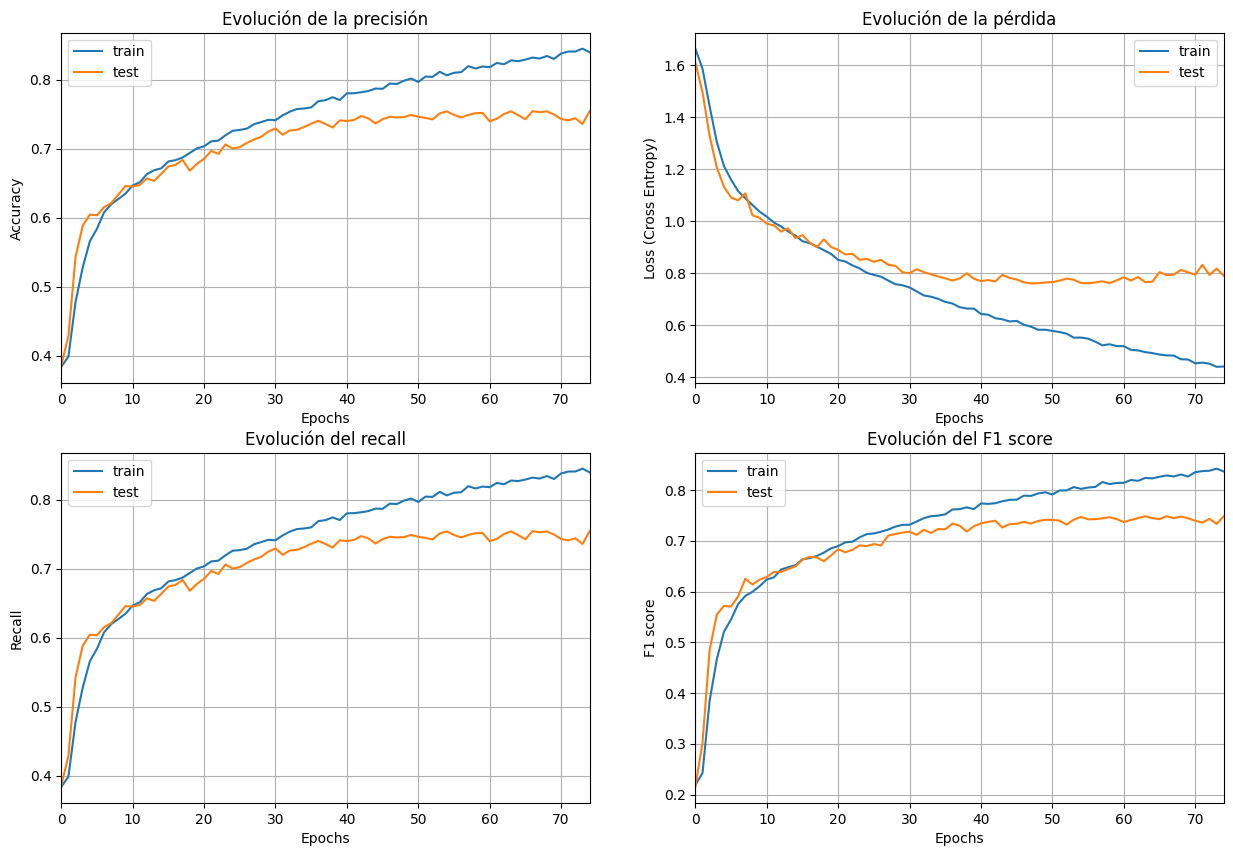

In [65]:
def plot_metrics(epochs, ac_evol, ac_evol_test, loss_evol, loss_evol_test, recall_evol, recall_evol_test, f1_evol, f1_evol_test):
    fig, axs = plt.subplots(2,2, figsize=(15,10))

    axs[0][0].plot(range(epochs), ac_evol, label='train')
    axs[0][0].plot(range(epochs), ac_evol_test, label='test')
    axs[0][0].set_title('Evolución de la precisión')
    axs[0][0].set_ylabel('Accuracy')
    axs[0][0].set_xlabel('Epochs')
    axs[0][0].set_xlim(0, epochs-1)
    axs[0][0].grid()
    axs[0][0].legend()

    axs[0][1].plot(range(epochs), loss_evol, label='train')
    axs[0][1].plot(range(epochs), loss_evol_test, label='test')
    axs[0][1].set_title('Evolución de la pérdida')
    axs[0][1].set_ylabel('Loss (Cross Entropy)')
    axs[0][1].set_xlabel('Epochs')
    axs[0][1].set_xlim(0, epochs-1)
    axs[0][1].grid()
    axs[0][1].legend()

    axs[1][0].plot(range(epochs), recall_evol, label='train')
    axs[1][0].plot(range(epochs), recall_evol_test, label='test')
    axs[1][0].set_title('Evolución del recall')
    axs[1][0].set_ylabel('Recall')
    axs[1][0].set_xlabel('Epochs')
    axs[1][0].set_xlim(0, epochs-1)
    axs[1][0].grid()
    axs[1][0].legend()

    axs[1][1].plot(range(epochs), f1_evol, label='train')
    axs[1][1].plot(range(epochs), f1_evol_test, label='test')
    axs[1][1].set_title('Evolución del F1 score')
    axs[1][1].set_ylabel('F1 score')
    axs[1][1].set_xlabel('Epochs')
    axs[1][1].set_xlim(0, epochs-1)
    axs[1][1].grid()
    axs[1][1].legend()

plot_metrics(epochs, ac_evol, ac_evol_test, loss_evol, loss_evol_test, recall_evol, recall_evol_test, f1_evol, f1_evol_test)

Realicemos un grid search para encontrar los valores óptimos de hiperparámetros: cantidad de capas convolucionales, canales por capa convolucional y tamaño del kernel. Todos los modelos se entrenan con learning rate 1e-3 por 40 epochs.

Además se divide el set de validación en la mitad en entrenamiento y validación con batch_size 128 para entrenamiento.

In [57]:
import pandas as pd
from sklearn.model_selection import train_test_split

data_train, data_val = train_test_split(torchvision.datasets.ImageFolder(root='datos_zip/dataset_emociones/train/', transform=composition), test_size=0.5)
dataloader_train = torch.utils.data.DataLoader(data_train, batch_size=128, shuffle=True)
# X_val, y_val = torch.tensor([data_val[i][0] for i in range(len(data_val))]) , torch.tensor([data_val[i][1] for i in range(len(data_val))])
X_val, y_val = [data_val[i][0] for i in range(len(data_val))] , [data_val[i][1] for i in range(len(data_val))]
X_val, y_val = torch.stack(X_val), torch.tensor(y_val)
X_val, y_val = X_val.to(device), y_val.to(device)
dataloader_val = torch.utils.data.DataLoader(data_val, batch_size=128, shuffle=True)
# hyperparameter grid search
models = []
for layers in [3,4,5]:
    for ch_per_layer in [4,8,12]:
        for kernel in [4,8,12]:
            model = CNN(device=device, img_size=100, in_channels=3, layers=layers, ch_per_layer=ch_per_layer, kernel_size=kernel, pool_kernel_size=2)
            print('Model with:')
            print(f'    layers={layers}')
            print(f'    ch_per_layer={ch_per_layer}')
            print(f'    kernel={kernel}')
            models.append({
                'layers' : layers,
                'ch_per_layer' : ch_per_layer,
                'kernel' : kernel
            })
            # torchinfo.summary(model, input_size=[1,3,100,100])

            optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
            loss = torch.nn.CrossEntropyLoss()

            ac_evol = []
            loss_evol = []
            epochs = 40

            for epoch in range(epochs):
                model.train()
                epoch_loss = []
                corrects = 0
                samples = 0
                # for x_i, y_i in dataloader['train']:
                for x_i, y_i in dataloader_train:
                    x_i, y_i = x_i.to(device), y_i.to(device)
                    yhat = model(x_i)
                    # yhat = yhat.squeeze(dim=1)
                    # yhat = torch.tensor(yhat.argmax(dim=1))
                    loss_i = loss(yhat, y_i)
                    optimizer.zero_grad(set_to_none=True)
                    loss_i.backward()
                    optimizer.step()
                    epoch_loss.append(loss_i.item())

                    preds_classes = yhat.argmax(dim=1)
                    corrects += (preds_classes == y_i).sum().item()
                    samples += y_i.size(0)
                    # print(f'ac={corrects/samples:.4f}')
                epoch_loss = np.mean(epoch_loss)
                loss_evol.append(epoch_loss)
                ac_evol.append(corrects/samples)
                # print(f'Epoch {epoch} Loss = {epoch_loss}')
                # print(f'Epoch {epoch} Accuracy = {100 * corrects/samples:.0f}%')
            print(f'Training loss = {epoch_loss}')
            print(f'Training accuracy = {ac_evol[-1]*100:.2f}%')
            models[-1]['train-loss'] = epoch_loss
            models[-1]['train-accuracy'] = ac_evol[-1]*100
            

            model.eval()
            # X_test, y_test = next(iter(dataloader['test']))
            with torch.no_grad():
                yhat_test = model(X_val)

            preds_classes_test = yhat_test.argmax(dim=1)
            corrects_test = (preds_classes_test == y_val).sum().item()
            samples_test = y_val.size(0)
            ac_test = corrects_test / samples_test
            print(f'Accuracy in test = {100*ac_test:.2f}%')
            models[-1]['test-accuracy'] = ac_test*100

hypr_gridsearch = pd.DataFrame(models)
hypr_gridsearch

----------------------------------------------
Red creada:
Sequential(
  (conv_0): Conv2d(3, 4, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
  (act_0): LeakyReLU(negative_slope=0.01)
  (pool_0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop_0): Dropout2d(p=0.1, inplace=False)
  (conv_1): Conv2d(4, 8, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
  (act_1): LeakyReLU(negative_slope=0.01)
  (pool_1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop_1): Dropout2d(p=0.1, inplace=False)
  (conv_2): Conv2d(8, 16, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
  (act_2): LeakyReLU(negative_slope=0.01)
  (pool_2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten()
  (drop): Dropout(p=0.1, inplace=False)
  (fully_connected): Linear(in_features=2704, out_features=7, bias=True)
)
----------------------------------------------
Model with:
    layers=3
    ch_per_laye

,layers,ch_per_layer,kernel,train-loss,train-accuracy,test-accuracy
0,3,4,4,0.559215,80.603097,68.758149
1,3,4,8,0.446848,83.390383,65.759452
2,3,4,12,0.317985,88.492258,66.932855
3,3,8,4,0.199999,92.909535,71.153846
4,3,8,8,0.097680,96.267319,69.295958
5,3,8,12,0.124867,95.680522,66.818774
6,3,12,4,0.077403,97.310513,70.567145
7,3,12,8,0.072928,97.603912,70.045632
8,3,12,12,0.134254,95.468623,66.541721
9,4,4,4,0.558250,79.413203,69.687093


Computamos la relación entre la precisión en entrenamiento y testeo, que nos servirá para ver si el modelo está sobreajustando.

In [58]:
hypr_gridsearch['train-test-rel'] = hypr_gridsearch['train-accuracy'] / hypr_gridsearch['test-accuracy']

A continuación vemos la relación entre precisión con el dataset de train y precisión con el dataset de validación. Lo ideal es tener un modelo que generalice a igual precisión que cuando entrena. Si el modelo presenta una precisión muy superior en entrenamiento frente a validación, esto nos indica que estamos teniendo sobre ajuste.

Podemos observar que:
- Al aumentar la cantidad de capas nos alejamos de la línea ideal, con 2 puntos buenos con 3 y 4 capas.
- Al aumentar la cantidad de canales por capa se tiene un efecto aún más marcado en la distancia al modelo ideal.
- Al aumentar el tamaño del kernel no se tiene tanta diferencia en algunos casos, pero si se aprecia que los mejores generalizadores tienen valor 4 de kernel

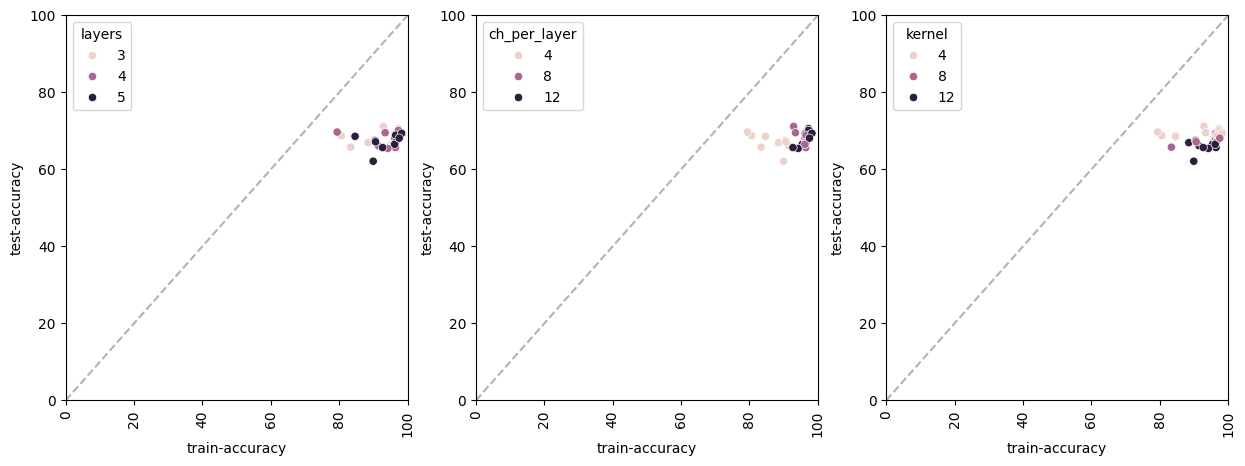

In [59]:
import seaborn as sns
fig, axs = plt.subplots(1,3,figsize=(15,5))
sns.scatterplot(data=hypr_gridsearch, x='train-accuracy' ,y='test-accuracy', hue='layers', ax=axs[0])
sns.scatterplot(data=hypr_gridsearch, x='train-accuracy' ,y='test-accuracy', hue='ch_per_layer', ax=axs[1])
sns.scatterplot(data=hypr_gridsearch, x='train-accuracy' ,y='test-accuracy', hue='kernel', ax=axs[2])
for i in range(3):
    axs[i].tick_params(axis='x', rotation=90)
    axs[i].set_ylim(0,100)
    axs[i].set_xlim(0,100)
    axs[i].plot([0,100],[0,100], linestyle='dashed', color='grey', alpha=0.6)
# plt.legend()

# plt.bar(hypr_gridsearch['train-accuracy'], y=)

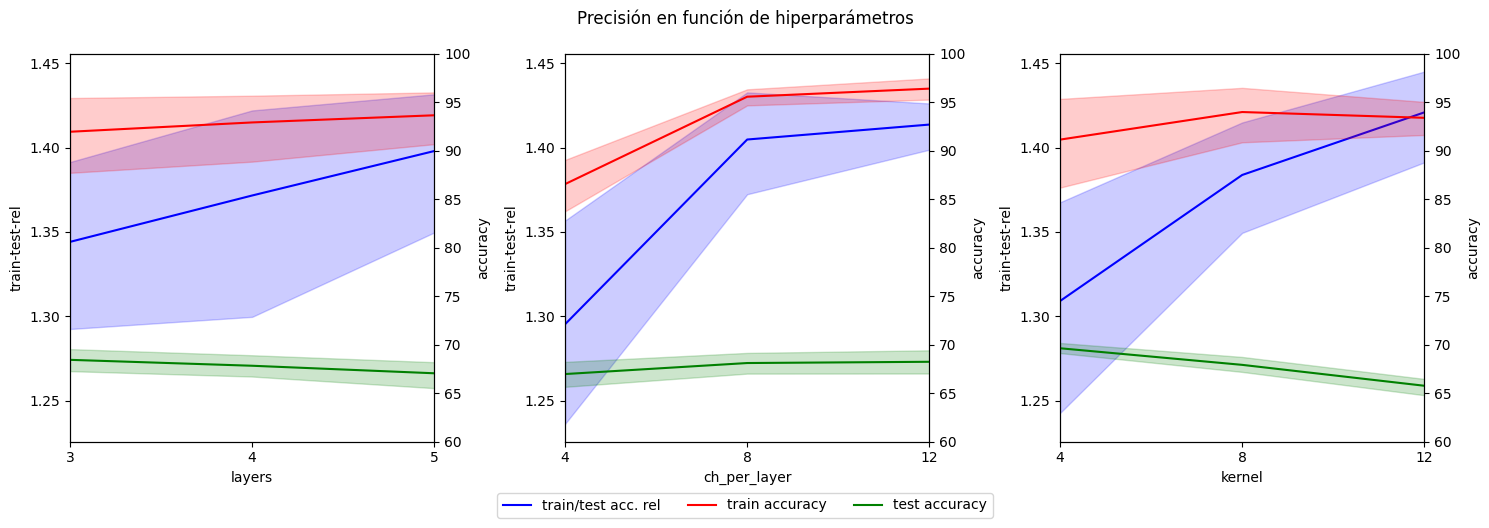

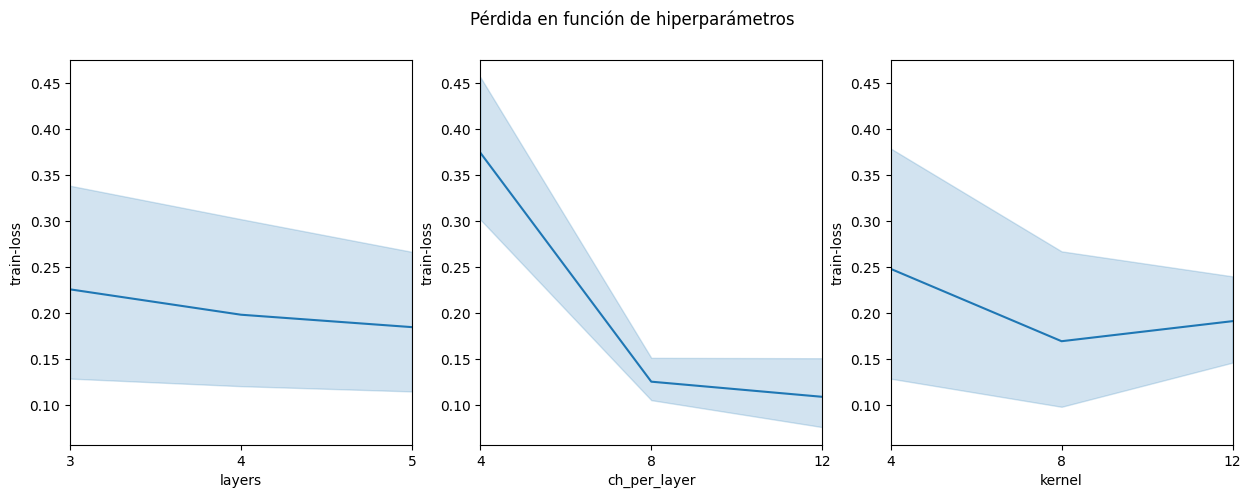

In [60]:
fig, axs = plt.subplots(1,3,figsize=(15,5),sharey=True)
# para mostrar los yticks en todos los gráficos
axs[1].yaxis.set_tick_params(labelbottom=True)
axs[2].yaxis.set_tick_params(labelbottom=True)

def hypr_comparison_plot(ax, hypr, data):
    ax.set_xlim(data[hypr].min(), data[hypr].max())
    ax.set_xticks(data[hypr].unique())
    sns.lineplot(data=data, x=hypr, y='train-test-rel',ax=ax, color='blue', label='train/test acc. rel')
    handles, labels = ax.get_legend_handles_labels()
    ax.get_legend().remove()
    ax_01 = ax.twinx()
    ax_01.set_ylabel('accuracy')
    ax_01.set_ylim(60,100)
    sns.lineplot(data=hypr_gridsearch, x=hypr, y='train-accuracy',ax=ax_01, color='red', label='train accuracy')
    sns.lineplot(data=hypr_gridsearch, x=hypr, y='test-accuracy',ax=ax_01, color='green', label='test accuracy')
    handles2, labels2 = ax_01.get_legend_handles_labels()
    ax_01.get_legend().remove()
    # ax.legend(handles=handles+handles2)
    return handles+handles2

handles = hypr_comparison_plot(ax=axs[0], hypr='layers', data=hypr_gridsearch)
_ = hypr_comparison_plot(ax=axs[1], hypr='ch_per_layer', data=hypr_gridsearch)
_ = hypr_comparison_plot(ax=axs[2], hypr='kernel', data=hypr_gridsearch)
fig.legend(
    handles=handles,
    bbox_to_anchor=(0.5, -0.05), 
    loc='lower center',
    ncol=3
)
fig.suptitle('Precisión en función de hiperparámetros')
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1,3,figsize=(15,5),sharey=True)
# para mostrar los yticks en todos los gráficos
axs[1].yaxis.set_tick_params(labelbottom=True)
axs[2].yaxis.set_tick_params(labelbottom=True)
for idx, hypr in enumerate(['layers', 'ch_per_layer', 'kernel']):
    sns.lineplot(data=hypr_gridsearch, x=hypr, y='train-loss',ax=axs[idx])
    axs[idx].set_xlim(hypr_gridsearch[hypr].min(), hypr_gridsearch[hypr].max())
    axs[idx].set_xticks(hypr_gridsearch[hypr].unique())
# sns.lineplot(data=hypr_gridsearch, x='ch_per_layer', y='train-loss',ax=axs[1])
# sns.lineplot(data=hypr_gridsearch, x='kernel', y='train-loss',ax=axs[2])
fig.suptitle('Pérdida en función de hiperparámetros')
plt.show()

Se tienen 2 tipos de gráficos en función de los hiperparámetros:
- Gráfico de precisión: se grafica la precisión en entrenamiento y en validación, así como también la relación entre ambos. Lo que se busca con esto último es intentar evitar tener sobreajuste, lo cual se evidencia al tener una precisión de entrenamiento muy superior a la de validación.
- Gráfico de pérdida de entrenamiento.

Analicemos los resultados:
- En cuanto al analísis de precisión en función de los hiperparámetros, se obtiene una relación casi igual en todos los casos, donde al tener un modelo más denso se empieza a tener sobreajuste, especialmente al aumentar la cantidad de capas y la dimensión del kernel. Con los canales por capa, se tiene un aumento de sobreajuste, aunque si se mejora (levemente) la precisión del set de validación, algo que con los otros 2 hiperparámetros empeora.
- En cuanto a la pérdida, observamos que al aumentar todos los hiperparámetros se disminuye la pérdida en el entrenamiento, pero nuevamente el hiperparámetro que más influencia tiene son los canales por capa, donde se parte del mayor valor y se termina en el menor valor de pérdida.

Se concluye utilizar la siguiente arquitectura:
- `layers` = 3
- `ch_per_layers` = 8
- `kernel` = 4

**Análisis del learning rate y epochs de entrenamiento**

A continuación se analzian 3 posibles learning rates: 1e-3, 1e-4, 5e-5. Los 3 casos se corren 200 epochs de entrenamiento. Se busca encontrar el learning rate óptimo y las epochs de entrenamiento óptimas.

In [61]:
lr_comp = {}
for lr in [1e-3, 1e-4, 5e-5]:
    model = CNN(device=device, img_size=100, in_channels=3, layers=3, ch_per_layer=8, kernel_size=4, pool_kernel_size=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    loss = torch.nn.CrossEntropyLoss()
    epochs = 200

    loss_evol, ac_evol, recall_evol, f1_evol, loss_evol_test, ac_evol_test, recall_evol_test, f1_evol_test = train_model(model, dataloader['train'], dataloader['test'], epochs, optimizer, loss)

    lr_comp[lr] = {}
    lr_comp[lr]['model'] = model
    lr_comp[lr]['loss_evol'] = loss_evol
    lr_comp[lr]['ac'] = ac_evol
    lr_comp[lr]['recall'] = recall_evol
    lr_comp[lr]['f1'] = f1_evol
    lr_comp[lr]['loss_evol_test'] = loss_evol_test
    lr_comp[lr]['ac_test'] = ac_evol_test
    lr_comp[lr]['recall_test'] = recall_evol_test
    lr_comp[lr]['f1_test'] = f1_evol_test

----------------------------------------------
Red creada:
Sequential(
  (conv_0): Conv2d(3, 8, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
  (act_0): LeakyReLU(negative_slope=0.01)
  (pool_0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop_0): Dropout2d(p=0.1, inplace=False)
  (conv_1): Conv2d(8, 16, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
  (act_1): LeakyReLU(negative_slope=0.01)
  (pool_1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop_1): Dropout2d(p=0.1, inplace=False)
  (conv_2): Conv2d(16, 32, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
  (act_2): LeakyReLU(negative_slope=0.01)
  (pool_2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten()
  (drop): Dropout(p=0.1, inplace=False)
  (fully_connected): Linear(in_features=5408, out_features=7, bias=True)
)
----------------------------------------------
Epoch 0:
 Train Loss = 1.5053
 Train A

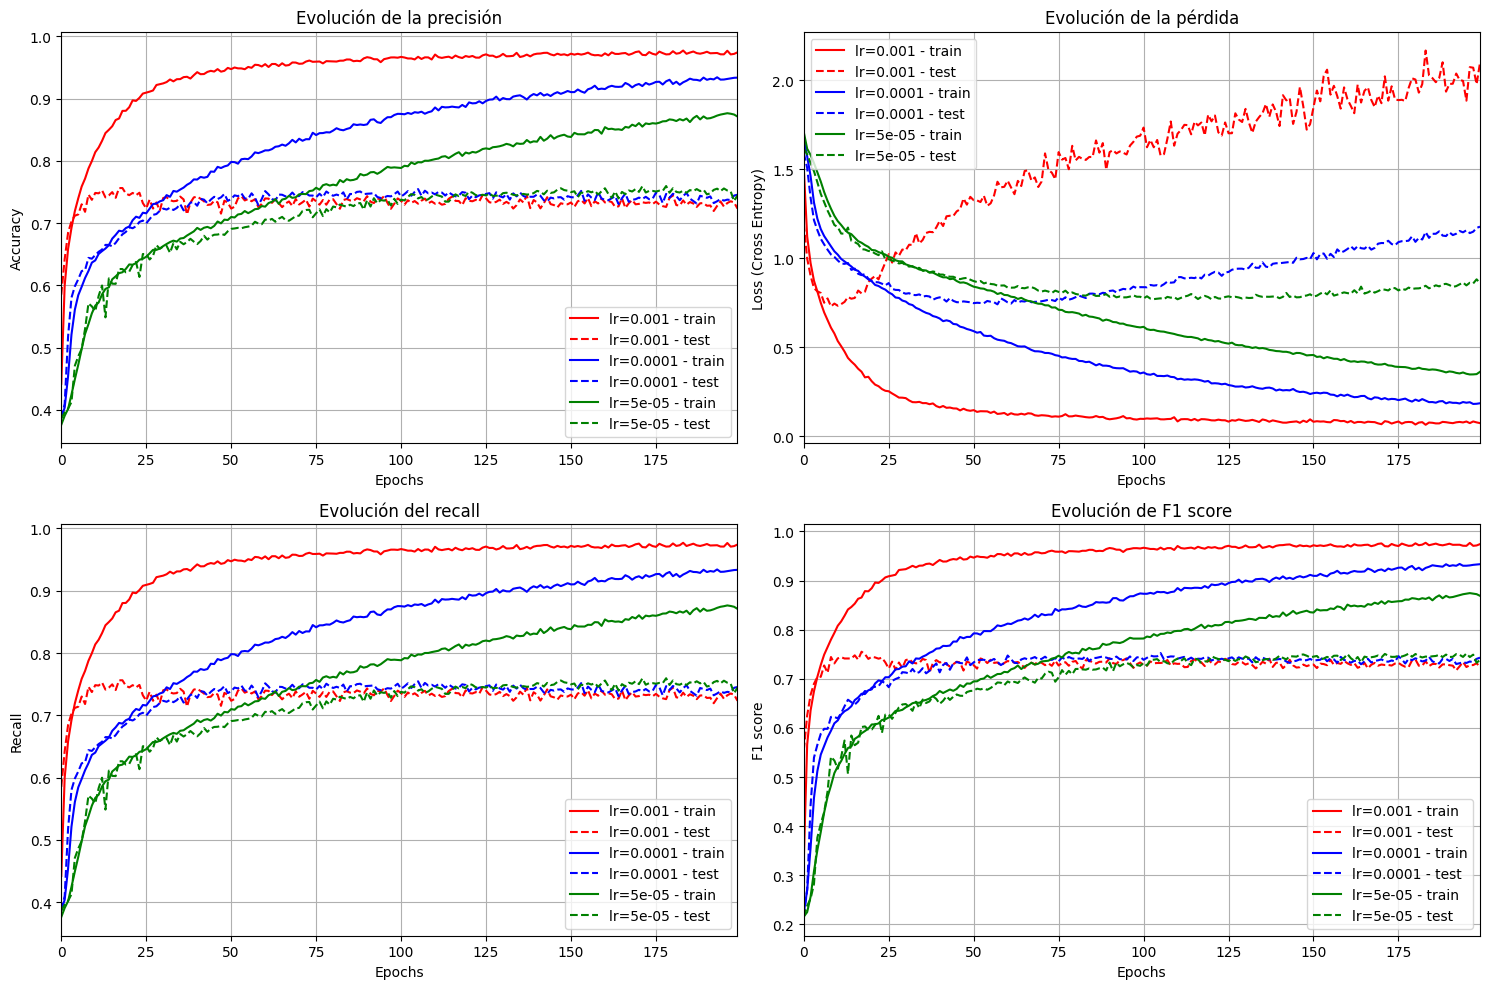

In [62]:
fig, axs = plt.subplots(2,2, figsize=(15,10))
colors = {
    1e-3: 'red',
    1e-4: 'blue',
    5e-5: 'green',
}
for lr in [1e-3, 1e-4, 5e-5]:
    axs[0][0].plot(range(epochs), lr_comp[lr]['ac'], label=f'lr={lr} - train', color=colors[lr])
    axs[0][0].plot(range(epochs), lr_comp[lr]['ac_test'], label=f'lr={lr} - test', color=colors[lr], linestyle='dashed')
# axs[0][0].plot([0, epochs-1], [ac_evol_test[-1], ac_evol_test[-1]] , label='test')
axs[0][0].set_title('Evolución de la precisión')
axs[0][0].set_ylabel('Accuracy')
axs[0][0].set_xlabel('Epochs')
axs[0][0].set_xlim(0, epochs-1)
axs[0][0].grid()
axs[0][0].legend()

for lr in [1e-3, 1e-4, 5e-5]:
    axs[0][1].plot(range(epochs), lr_comp[lr]['loss_evol'], label=f'lr={lr} - train', color=colors[lr])
    axs[0][1].plot(range(epochs), lr_comp[lr]['loss_evol_test'], label=f'lr={lr} - test', color=colors[lr], linestyle='dashed')
axs[0][1].set_title('Evolución de la pérdida')
axs[0][1].set_ylabel('Loss (Cross Entropy)')
axs[0][1].set_xlabel('Epochs')
axs[0][1].set_xlim(0, epochs-1)
axs[0][1].grid()
axs[0][1].legend()

for lr in [1e-3, 1e-4, 5e-5]:
    axs[1][0].plot(range(epochs), lr_comp[lr]['recall'], label=f'lr={lr} - train', color=colors[lr])
    axs[1][0].plot(range(epochs), lr_comp[lr]['recall_test'], label=f'lr={lr} - test', color=colors[lr], linestyle='dashed')
axs[1][0].set_title('Evolución del recall')
axs[1][0].set_ylabel('Recall')
axs[1][0].set_xlabel('Epochs')
axs[1][0].set_xlim(0, epochs-1)
axs[1][0].grid()
axs[1][0].legend()

for lr in [1e-3, 1e-4, 5e-5]:
    axs[1][1].plot(range(epochs), lr_comp[lr]['f1'], label=f'lr={lr} - train', color=colors[lr])
    axs[1][1].plot(range(epochs), lr_comp[lr]['f1_test'], label=f'lr={lr} - test', color=colors[lr], linestyle='dashed')
axs[1][1].set_title('Evolución de F1 score')
axs[1][1].set_ylabel('F1 score')
axs[1][1].set_xlabel('Epochs')
axs[1][1].set_xlim(0, epochs-1)
axs[1][1].grid()
axs[1][1].legend()

plt.tight_layout()
plt.show()

Se observa que con learning rate 1e-4 se tiene un buen balance entre métricas de entrenamiento y de evaluación. La cantidad de epochs también es importante, ya que se puede observar como a partir de cierta cantidad de epochs se empieza a separar la curva de entrenamiento de la de evaluación, indicando que se comienza a tener sobreajuste. Por este motivo se decide utilizar 75 epochs para el entrenamiento del modelo.

Entrenamos el modelo teniendo esto en cuenta:

In [63]:
epochs = 75
lr = 1e-4

model = CNN(device=device, img_size=100, in_channels=3, layers=3, ch_per_layer=8, kernel_size=4, pool_kernel_size=2)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss = torch.nn.CrossEntropyLoss()

loss_evol, ac_evol, recall_evol, f1_evol, loss_evol_test, ac_evol_test, recall_evol_test, f1_evol_test = train_model(model, dataloader['train'], dataloader['test'], epochs, optimizer, loss)

----------------------------------------------
Red creada:
Sequential(
  (conv_0): Conv2d(3, 8, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
  (act_0): LeakyReLU(negative_slope=0.01)
  (pool_0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop_0): Dropout2d(p=0.1, inplace=False)
  (conv_1): Conv2d(8, 16, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
  (act_1): LeakyReLU(negative_slope=0.01)
  (pool_1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop_1): Dropout2d(p=0.1, inplace=False)
  (conv_2): Conv2d(16, 32, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
  (act_2): LeakyReLU(negative_slope=0.01)
  (pool_2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten()
  (drop): Dropout(p=0.1, inplace=False)
  (fully_connected): Linear(in_features=5408, out_features=7, bias=True)
)
----------------------------------------------
Epoch 0:
 Train Loss = 1.6626
 Train A

## 3. Evaluación del Modelo (2.5 puntos)

El modelo entrenado debe ser evaluado utilizando las siguientes métricas:

- **Accuracy**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **F1 Score**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **Costo (Loss)**:
  - Mostrar una gráfica de evolución del costo por época para entrenamiento y validación.

- **Classification report**
  - Mostrar la precisión, recall y F1 score por cada clase usando `classification_report`

- **Matriz de confusión**:
  - Mostrar la matriz de confusión absoluta (valores enteros).
  - Mostrar la matriz de confusión normalizada (valores entre 0 y 1 por fila).

Se recomienda utilizar `scikit-learn` para calcular métricas como accuracy, F1 score, el Classification report y las matrices de confusión. Las visualizaciones pueden realizarse con `matplotlib` o `seaborn`, separando claramente los datos de entrenamiento y validación en las gráficas.


A continuación se tienen los gráficos de métricas en función de las epochs entrenadas:

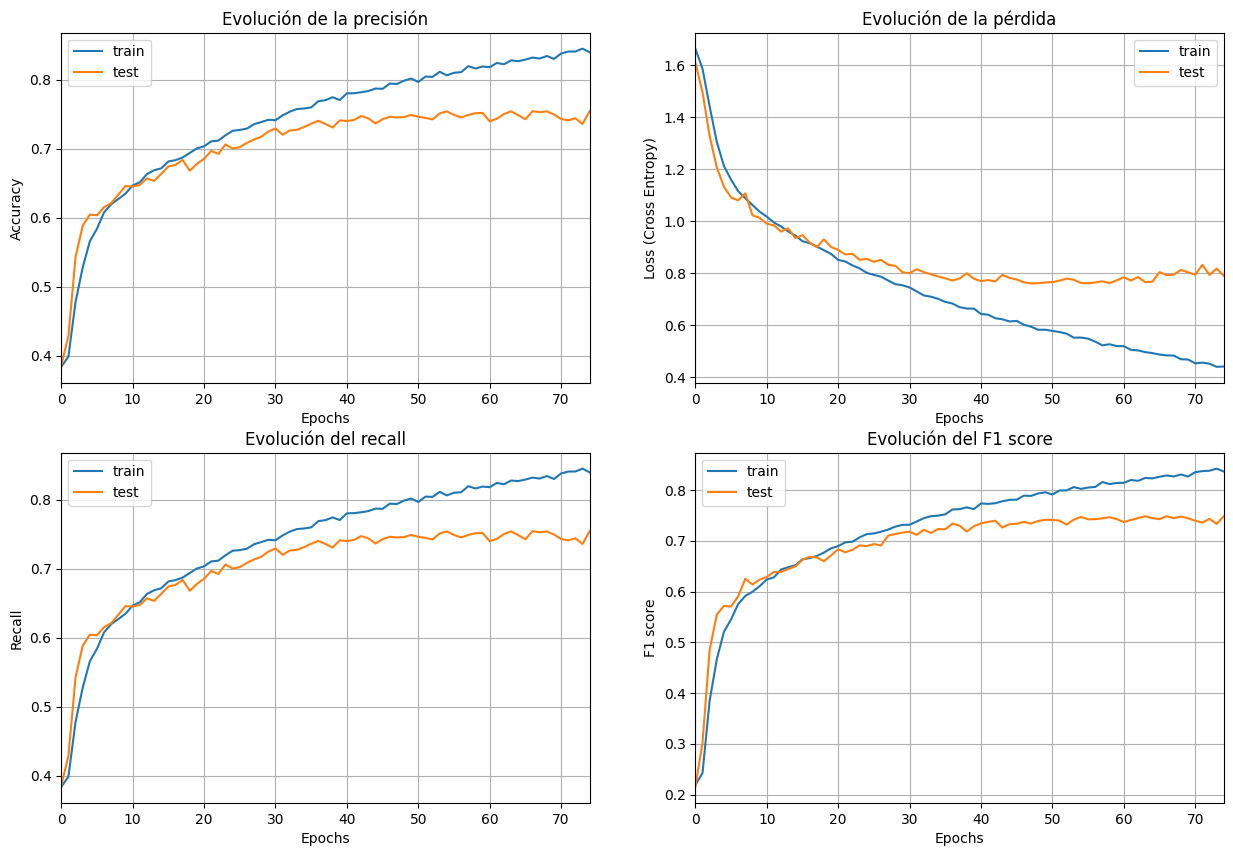

In [66]:
plot_metrics(epochs, ac_evol, ac_evol_test, loss_evol, loss_evol_test, recall_evol, recall_evol_test, f1_evol, f1_evol_test)

Evaluemos el modelo entrenado con los datasets de entrenamiento y de evaluación:

In [67]:
y_train = []
yhat_train = []

model.eval()
with torch.no_grad():
    for x_tr, y_tr in dataloader['train']:
        x_tr = x_tr.to(device)
        yhat_tr = model(x_tr)
        y_train.append(y_tr)
        yhat_train.append(yhat_tr.cpu())

    x_test, y_test = next(iter(dataloader['test']))
    x_test = x_test.to(device) 
    yhat_test = model(x_test)
    yhat_test = yhat_test.cpu()

y_train = torch.cat(y_train, dim=0)
yhat_train = torch.cat(yhat_train, dim=0)
yhat_train = yhat_train.argmax(dim=1)

yhat_test = yhat_test.argmax(dim=1)


Las principales métricas finales para entrenamiento y test son:

In [68]:
metrics = {
    'Train': {
        'Accuracy' : accuracy_score(y_train, yhat_train),
        'Recall' : recall_score(y_train, yhat_train, average='weighted'),
        'F1 score' : f1_score(y_train, yhat_train, average='weighted'),
    },
    'Test': {
        'Accuracy' : accuracy_score(y_test, yhat_test),
        'Recall' : recall_score(y_test, yhat_test, average='weighted'),
        'F1 score' : f1_score(y_test, yhat_test, average='weighted'),
    },
}
metrics = pd.DataFrame(metrics)
metrics

,Train,Test
Accuracy,0.895282,0.754563
Recall,0.895282,0.754563
F1 score,0.894119,0.748233


Tenemos el siguiente clasification report:

In [69]:
cr_train = classification_report(y_train, yhat_train)
print('Classification report para dataset de train')
print(cr_train)
cr_test = classification_report(y_test, yhat_test)
print('\nClassification report para dataset de test')
print(cr_test)


Classification report para dataset de train
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      4772
           1       0.89      0.67      0.76       717
           2       0.92      0.90      0.91       705
           3       0.98      0.83      0.90       281
           4       0.82      0.91      0.87      2524
           5       0.92      0.90      0.91      1290
           6       0.87      0.81      0.84      1982

    accuracy                           0.90     12271
   macro avg       0.91      0.85      0.88     12271
weighted avg       0.90      0.90      0.89     12271


Classification report para dataset de test
              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1185
           1       0.49      0.31      0.38       160
           2       0.61      0.65      0.63       162
           3       0.67      0.42      0.52        74
           4       0.69      0.76      0.72 

Observamos muy buenas métricas para la clase 0 (alegría), y el resto de clases tienen métricas bastante similares. Esto es esperable ya que la clase 0 es la que más datos tiene. Luego sorprende las buenas métricas de la clase menos representada (miedo), es probable que debido a que las expresiones utilizadas son muy diferenciables del resto. La emoción menos distinguible para el modelo resulto disgusto.

Y a continuación tenemos las matrices de confusión (nominales y normalizadas), donde podemos ver como:
- alegría una muy alta tasa de verdadero positivo, peor a costa de tener bastantes falsos positivos, especialmente en el set de test. Es confundida incluso con tristeza, una emoción muy alejada.
- disgusto tiene una altísima falta de precisión, teniendo 31% en el dataset de test. Es principalmente confundida con seriedad, lo cual tiene sentido
- miedo también tiene baja tasa de precisión, siendo confundido principalmente con sorpresa. Probablemente esto se deba a que el modelo confunde la boca abierta por sorpresa con la boca abierta por un grito por el miedo.
- seriedad tiene una buena tasa de verdadero positivo, aunque tiene bastante falso positivo, confundiendo con disgusto, sorpresa y tristeza. Es posible que esto sea porque queda como una emoción 'neutra', y captura expresiones menos efusivas de las emociones mencionadas.
- enojo y tristeza tienen comportamiento similar con una precisión del ~60%, pero teniendo falsos positivos y falsos negativos desparramados en el resto de las emociones.
- sorpresa tiene buena precisión, pero, como se mencionó antes, confunde al miedo con sorpresa dando bastantes falsos positivos.

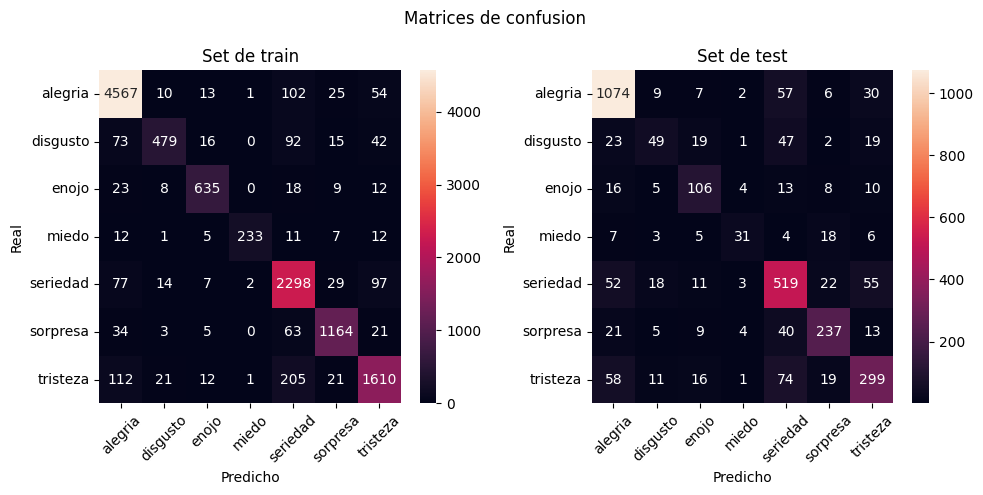

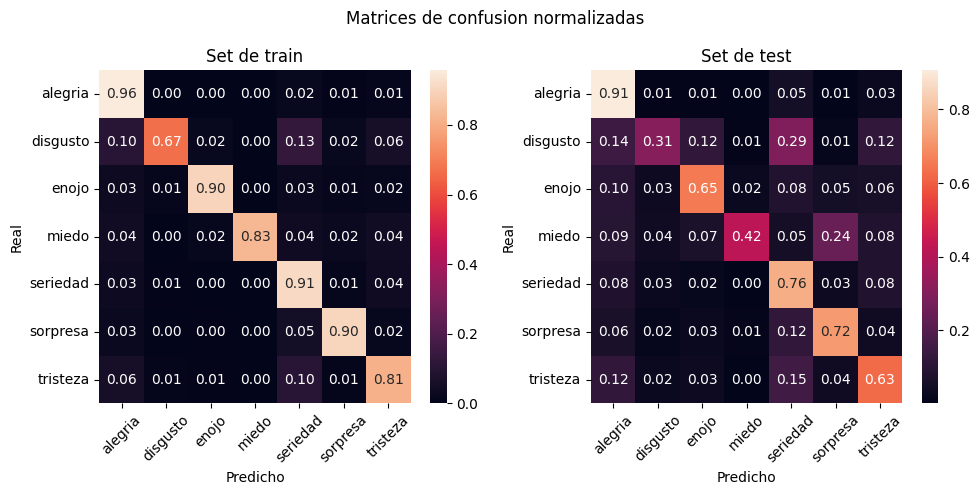

In [70]:
cm_train = confusion_matrix(y_train, yhat_train)
cm_test = confusion_matrix(y_test, yhat_test)

fig, axs = plt.subplots(1,2,figsize=(10,5))
sns.heatmap(data=cm_train, ax=axs[0], annot=True, fmt='d')
sns.heatmap(data=cm_test, ax=axs[1], annot=True, fmt='d')
axs[0].set_title('Set de train')
axs[1].set_title('Set de test')
[axs[i].set_xlabel('Predicho') for i in range(2)]
[axs[i].set_ylabel('Real') for i in range(2)]
[axs[i].set_xticks(np.arange(7) + 0.5,['alegria', 'disgusto', 'enojo', 'miedo', 'seriedad', 'sorpresa', 'tristeza'], rotation=45) for i in range(2)]
[axs[i].set_yticks(np.arange(7) + 0.5,['alegria', 'disgusto', 'enojo', 'miedo', 'seriedad', 'sorpresa', 'tristeza'], rotation=0) for i in range(2)]
fig.suptitle('Matrices de confusion')
plt.tight_layout()
plt.show()

cm_train_norm = confusion_matrix(y_train, yhat_train, normalize='true')
cm_test_norm = confusion_matrix(y_test, yhat_test, normalize='true')

fig, axs = plt.subplots(1,2,figsize=(10,5))
sns.heatmap(data=cm_train_norm, ax=axs[0], annot=True, fmt='.2f')
sns.heatmap(data=cm_test_norm, ax=axs[1], annot=True, fmt='.2f')
axs[0].set_title('Set de train')
axs[1].set_title('Set de test')
[axs[i].set_xlabel('Predicho') for i in range(2)]
[axs[i].set_ylabel('Real') for i in range(2)]
[axs[i].set_xticks(np.arange(7) + 0.5,['alegria', 'disgusto', 'enojo', 'miedo', 'seriedad', 'sorpresa', 'tristeza'], rotation=45) for i in range(2)]
[axs[i].set_yticks(np.arange(7) + 0.5,['alegria', 'disgusto', 'enojo', 'miedo', 'seriedad', 'sorpresa', 'tristeza'], rotation=0) for i in range(2)]
fig.suptitle('Matrices de confusion normalizadas')
plt.tight_layout()
plt.show()


 ## 4. Prueba de Imágenes Nuevas (1 punto)
Subir al menos 10 imágenes personales de cualquier relación de aspecto (pueden usar fotos del rostro de ustedes, rostros de personas generadas por IA o imágenes stock de internet), que no formen parte del dataset de entrenamiento ni de validación.

- Debe haber al menos una imagen para cada emoción.

- Aplicar el mismo pre-procesamiento que se usó para el dataset de validation durante el entrenamiento del modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:

  - La imagen original
  - La imagen pre-procesada (mismas transformaciones del entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase ganadora inferida por el modelo

- Redactar conclusiones preliminares

Importmaos las imagenes nuevas, teniendo un dataloader para las imagenes sin procesamiento y otro con procesamiento.

In [ ]:
new_data_org = torch.utils.data.DataLoader(torchvision.datasets.ImageFolder(root='my_dataset/', transform=transforms.ToTensor()), batch_size=1)
new_data = torch.utils.data.DataLoader(torchvision.datasets.ImageFolder(root='my_dataset/', transform=composition), batch_size=1)

Evaluamos el modelo con estas nuevas imagenes:

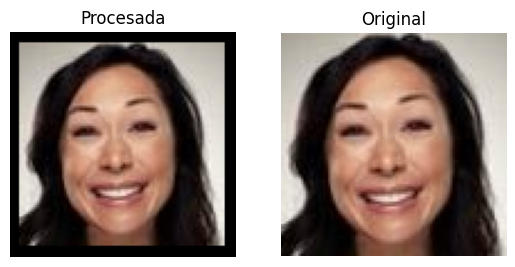

 alegria  disgusto    enojo    miedo  seriedad  sorpresa  tristeza
0.515319       0.0 0.586778 0.959809  0.166051  0.941383       1.0
Emocion predicha: tristeza
Emocion real: alegria


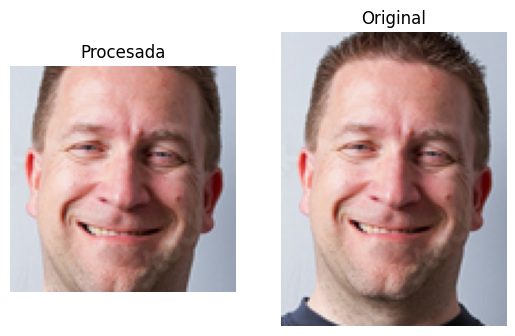

 alegria  disgusto  enojo    miedo  seriedad  sorpresa  tristeza
0.459211  0.431535    1.0 0.191213       0.0   0.16327  0.425901
Emocion predicha: enojo
Emocion real: alegria


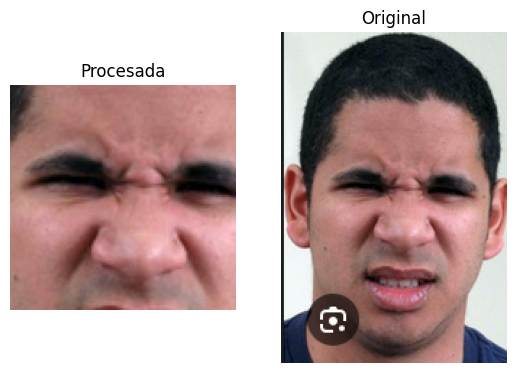

 alegria  disgusto    enojo  miedo  seriedad  sorpresa  tristeza
 0.85864   0.35845 0.656352    0.0       1.0  0.291699  0.465107
Emocion predicha: seriedad
Emocion real: disgusto


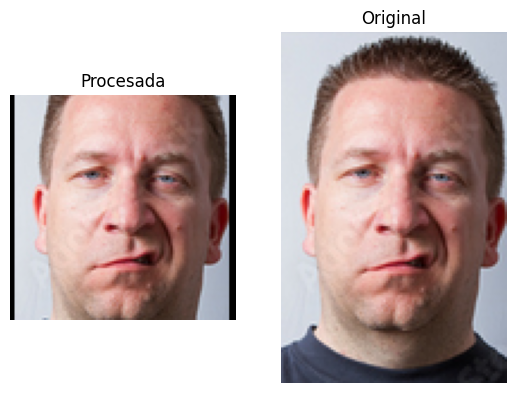

 alegria  disgusto  enojo  miedo  seriedad  sorpresa  tristeza
0.244498  0.569671    1.0    0.0  0.444128   0.67884  0.336578
Emocion predicha: enojo
Emocion real: disgusto


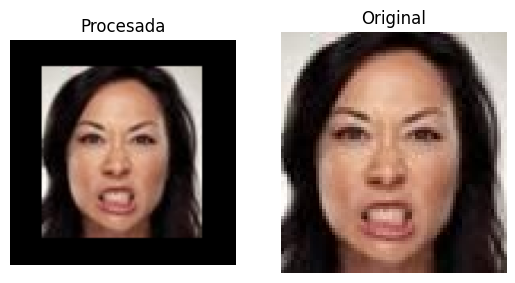

 alegria  disgusto    enojo  miedo  seriedad  sorpresa  tristeza
0.179828  0.115179 0.322167    1.0       0.0  0.591649  0.867021
Emocion predicha: miedo
Emocion real: enojo


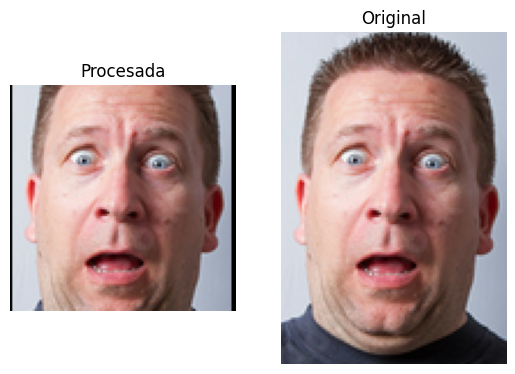

 alegria  disgusto    enojo    miedo  seriedad  sorpresa  tristeza
0.241559       0.0 0.492835 0.581476  0.361526       1.0  0.610463
Emocion predicha: sorpresa
Emocion real: miedo


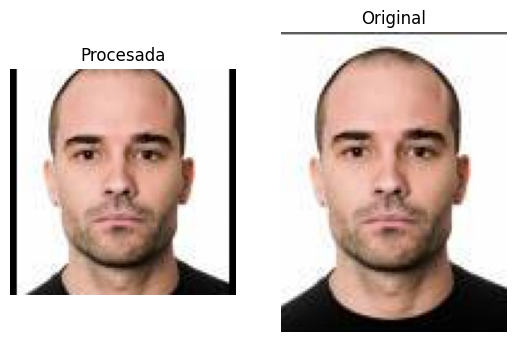

 alegria  disgusto  enojo    miedo  seriedad  sorpresa  tristeza
0.387207  0.499553    1.0 0.316787  0.221591       0.0   0.51832
Emocion predicha: enojo
Emocion real: seriedad


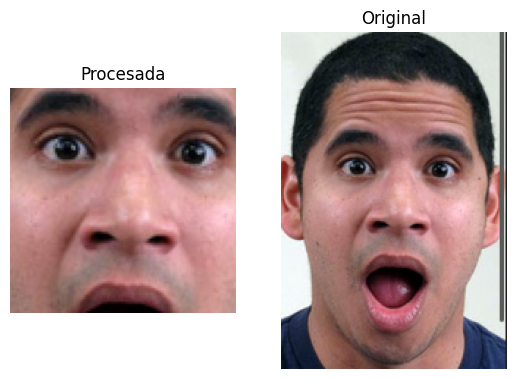

 alegria  disgusto    enojo  miedo  seriedad  sorpresa  tristeza
0.892167  0.353078 0.253045    0.0  0.880357       1.0  0.678397
Emocion predicha: sorpresa
Emocion real: sorpresa


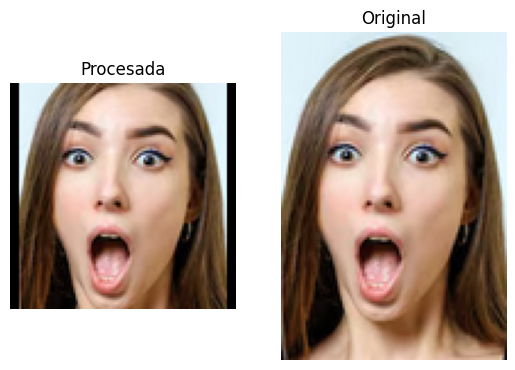

 alegria  disgusto  enojo   miedo  seriedad  sorpresa  tristeza
0.158052  0.106927    0.0 0.32175   0.35298       1.0  0.666372
Emocion predicha: sorpresa
Emocion real: sorpresa


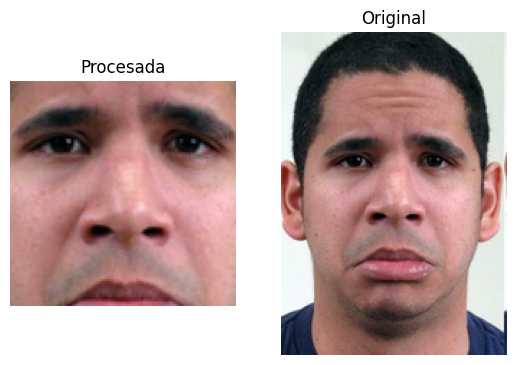

 alegria  disgusto    enojo    miedo  seriedad  sorpresa  tristeza
0.529398       0.0 0.030258 0.125235  0.238306       1.0  0.507907
Emocion predicha: sorpresa
Emocion real: tristeza


In [72]:
emociones = ['alegria', 'disgusto', 'enojo', 'miedo', 'seriedad', 'sorpresa', 'tristeza']
summary = []
for i, (batch_1, batch_2) in enumerate(zip(new_data, new_data_org)):
    x, y = batch_1
    x_org, _ = batch_2

    # visualizacion de las imagenes
    img_np = torch.clamp(x, 0, 1).permute(0,2,3,1).numpy()[0]
    img_np_org = torch.clamp(x_org, 0, 1).permute(0,2,3,1).numpy()[0]
    fig, axs = plt.subplots(1,2)
    axs[0].imshow(img_np)
    axs[0].set_title('Procesada')
    axs[1].imshow(img_np_org)
    axs[1].set_title('Original')
    [axs[i].set_axis_off() for i in range(2)]
    plt.show()

    # prediccion de la clase con el modelo
    x = x.to(device)
    model.eval()
    with torch.no_grad():
        yhat = model(x)
    # normalize y hat
    yhat = yhat.cpu().numpy().flatten()
    yhat_min, yhat_max = yhat.min(), yhat.max()
    for i in range(len(yhat)):
        val = yhat[i]
        yhat[i] = (val - yhat_min)/(yhat_max - yhat_min)
    yhat_df = pd.DataFrame([yhat], columns=emociones)
    print(yhat_df.to_string(index=False))
    # valor predicho
    predicted = yhat.argmax()
    print(f'Emocion predicha: {emociones[predicted]}')
    print(f'Emocion real: {emociones[y]}')

    summary.append([emociones[y], emociones[predicted]])


A continuación tenemos el resumen de lo real y lo predicho.

In [73]:
print('Resumen:')
print(pd.DataFrame(summary, columns=['Real', 'Predicho']))

Resumen:
       Real  Predicho
0   alegria  tristeza
1   alegria     enojo
2  disgusto  seriedad
3  disgusto     enojo
4     enojo     miedo
5     miedo  sorpresa
6  seriedad     enojo
7  sorpresa  sorpresa
8  sorpresa  sorpresa
9  tristeza  sorpresa


Podemos observar que el modelo tiende a confundir alegría con enojo, lo cual es raro porque en las matrices de confusión se veía que la alegría era la emoción que mejor tasa de verdaderos positivos entregaba.

También el modelo confundía seriedad con enojo, miedo con sorpesa y seriedad con enojo. Esto no resulta extraño, ya que podrían confundirse las expresiones en estos casos.

En esta pequeña prueba los verdaderos positivos del modelo fueron 4/10, lo cual está bastante por debajo de los valores de precisión que se vieron anteriormente.

 ## 5. Prueba de Imágenes Nuevas con Pre-procesamiento Adicional (1 punto)
Las 10 imágenes del punto 4, ahora serán pasadas y recortadas por un algoritmo de detección de rostros. Usen el siguiente código para realizar un pre-procesamiento inicial de la imagen y ya luego aplican el pre-procesamiento que usaron al momento de entrenar el modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:
  - La imagen original
  - La imagen recortada por el algoritmo
  - La imagen pre-procesada (mismas transformaciones del entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase ganadora inferida por el modelo

- Comparar los resultados con el punto 4 y redactar conclusiones finales.

NOTA: Pueden adaptar el código y modificar el `scaleFactor` y el `minNeighbors` según crean conveniente para obtener mejores resultados.

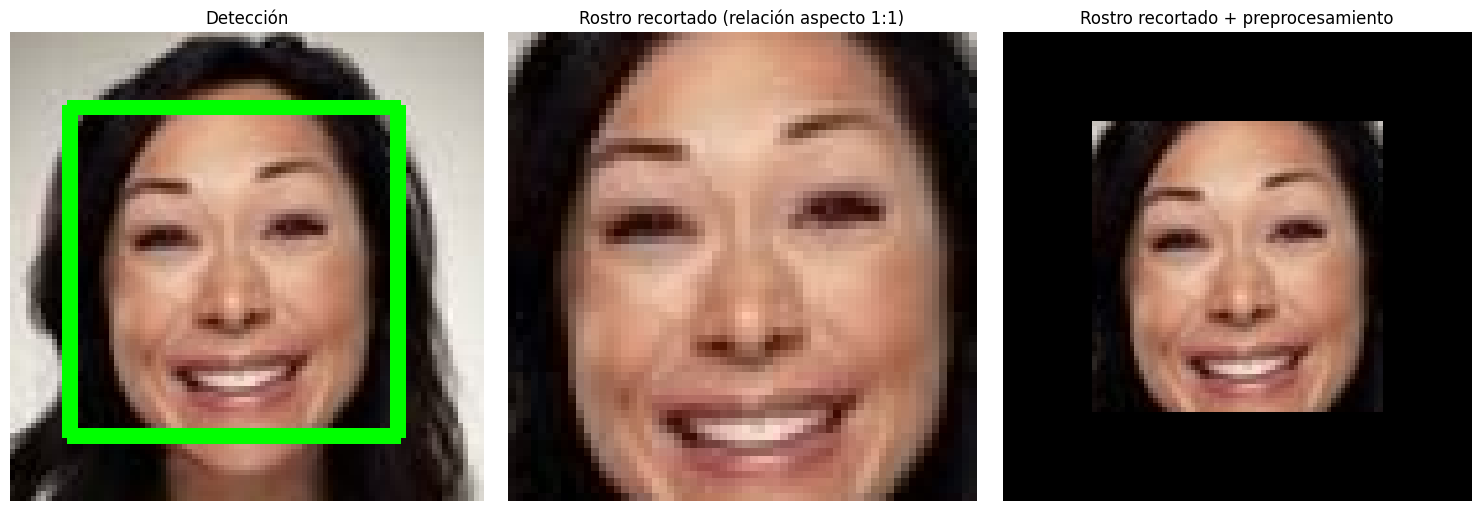

tensor([[-1.3028, -4.7624,  0.6615,  3.0307, -4.5012,  0.9329, -4.5979]])
miedo


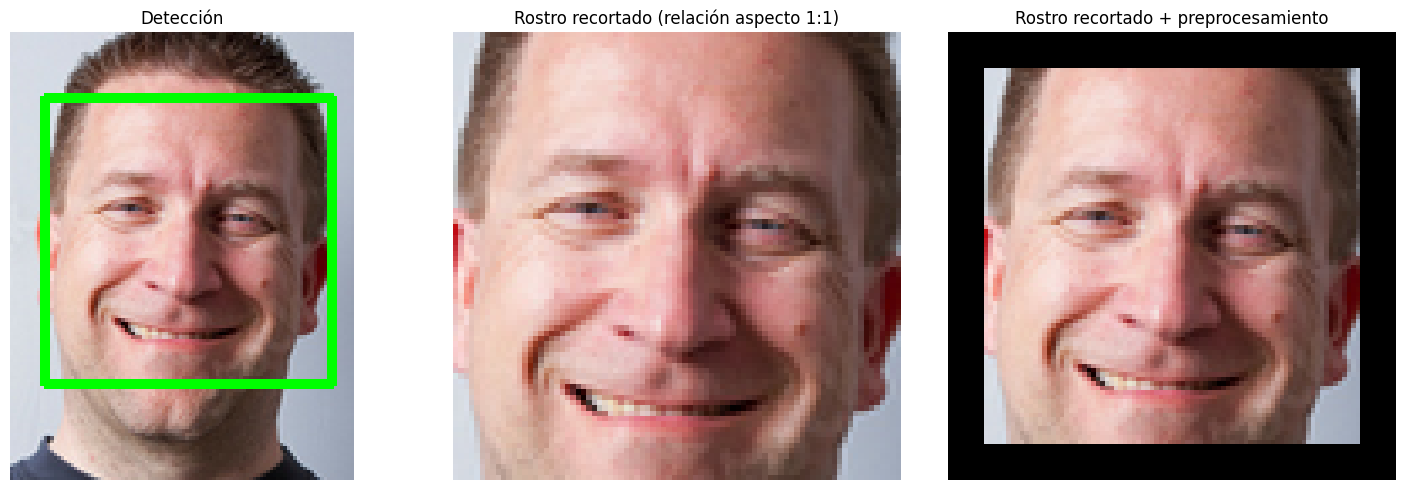

tensor([[ -6.9882, -11.0440,  -2.5306,  -0.1313,  -4.8413,  -3.5650,   2.7295]])
tristeza


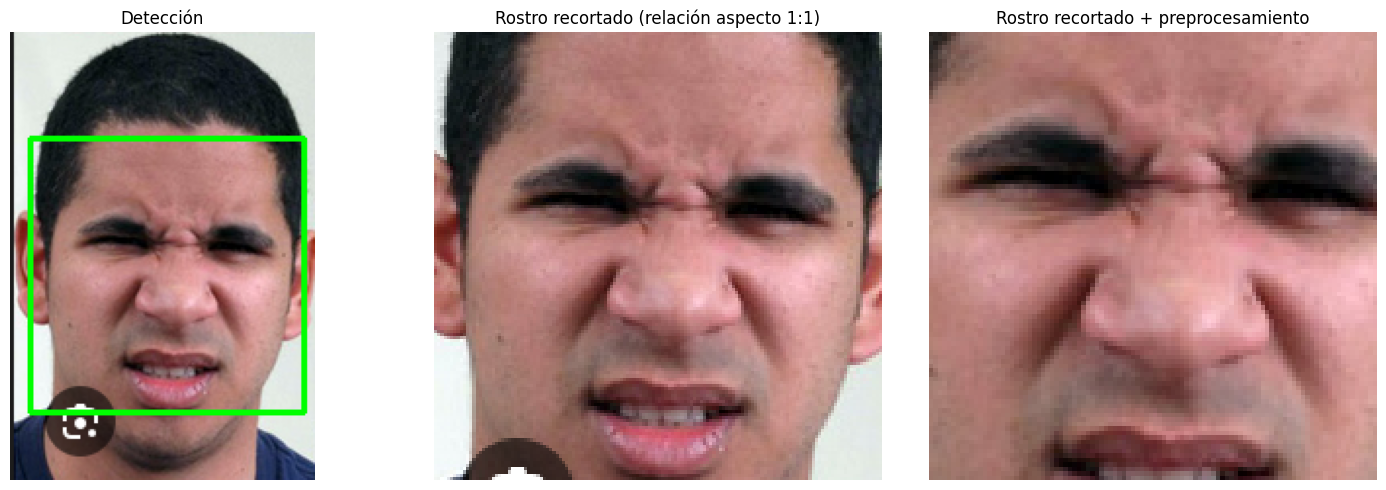

tensor([[-0.6326, -1.7892,  1.4313, -7.1226, -1.5968, -5.0094, -1.2080]])
enojo


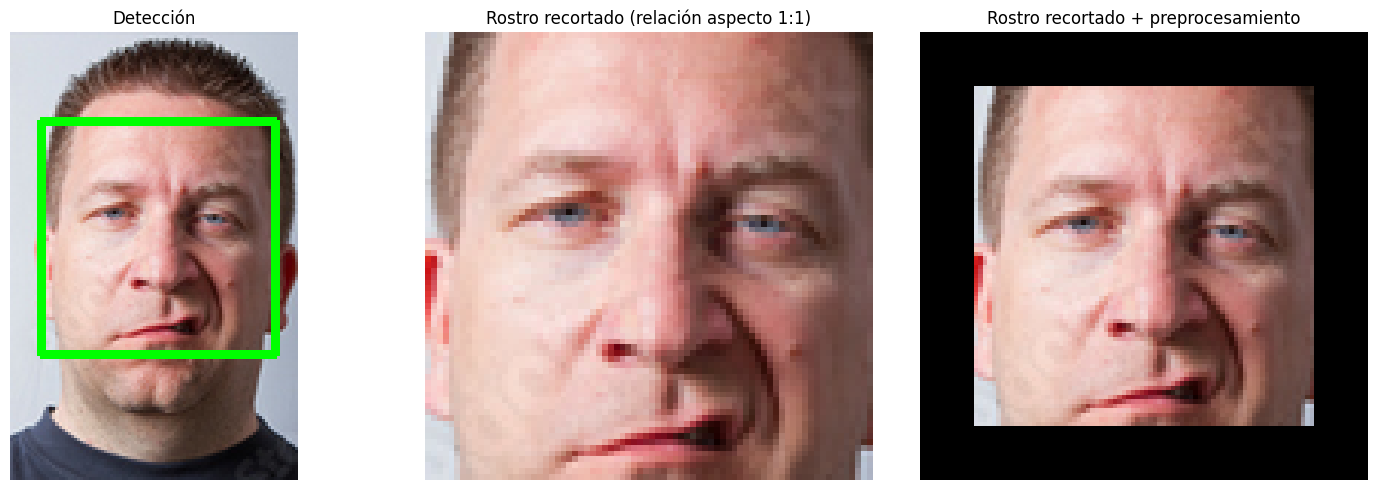

tensor([[ -5.4606, -10.7368,  -1.8406,  -2.2009,  -6.2052,  -1.6495,   3.3007]])
tristeza


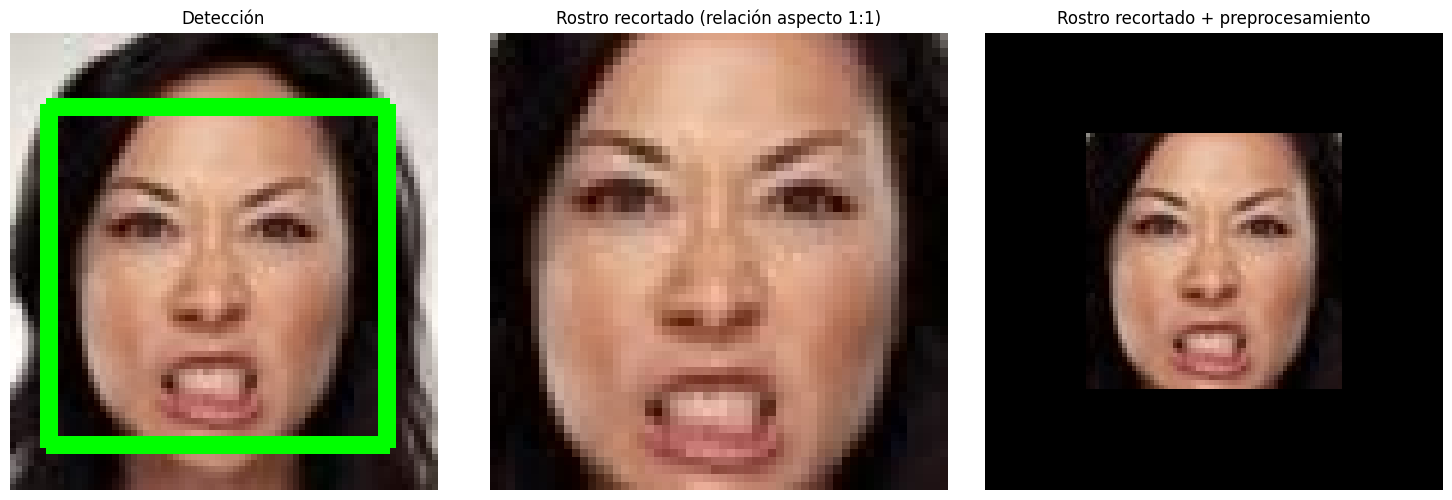

tensor([[-2.4431, -5.8658,  0.2662,  3.2137, -2.5837,  2.3363, -4.3124]])
miedo


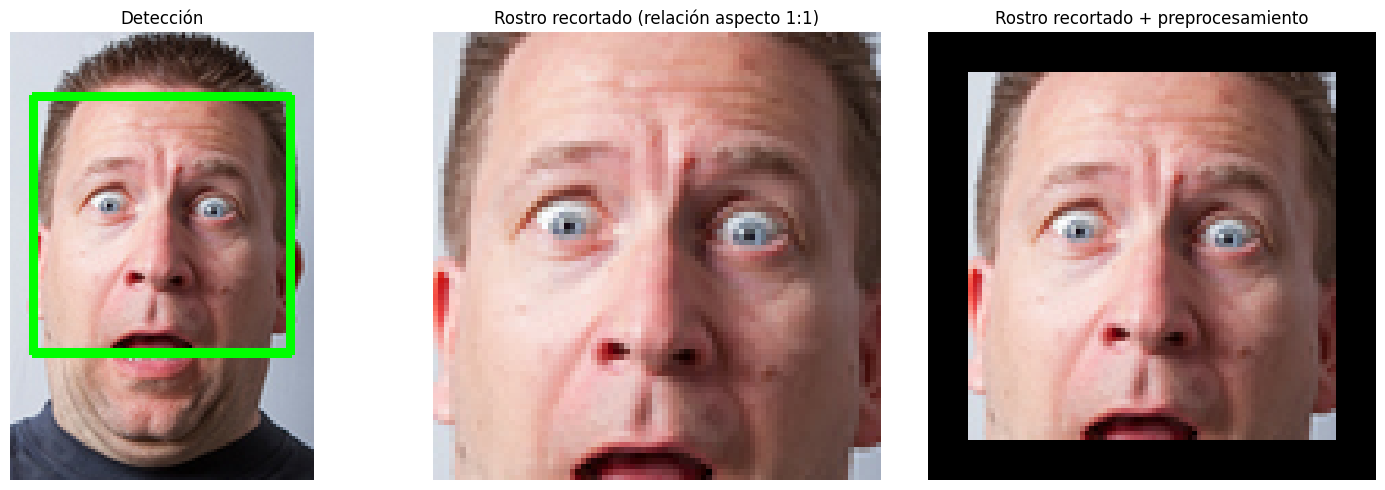

tensor([[-7.2009, -7.6209, -1.0815, -3.3395, -4.2292,  0.4297,  0.2826]])
sorpresa


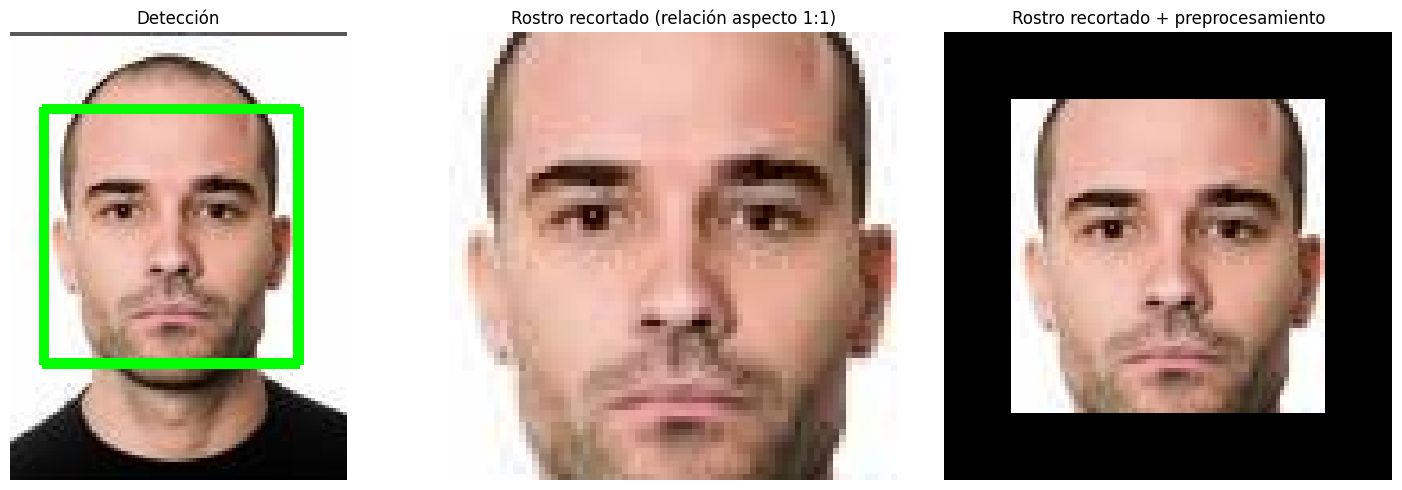

tensor([[-4.2138, -4.7751, -3.6235,  2.2426, -2.4565, -4.7372, -2.9033]])
miedo


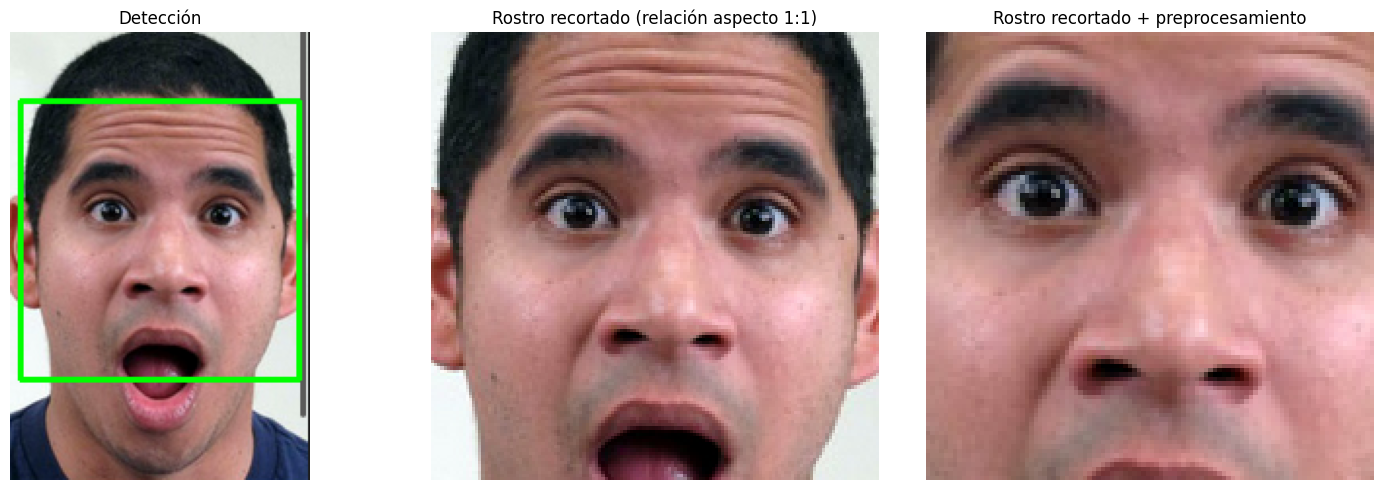

tensor([[ 0.4214, -6.3276, -5.4152, -5.0317, -2.1895,  1.1851, -3.9218]])
sorpresa


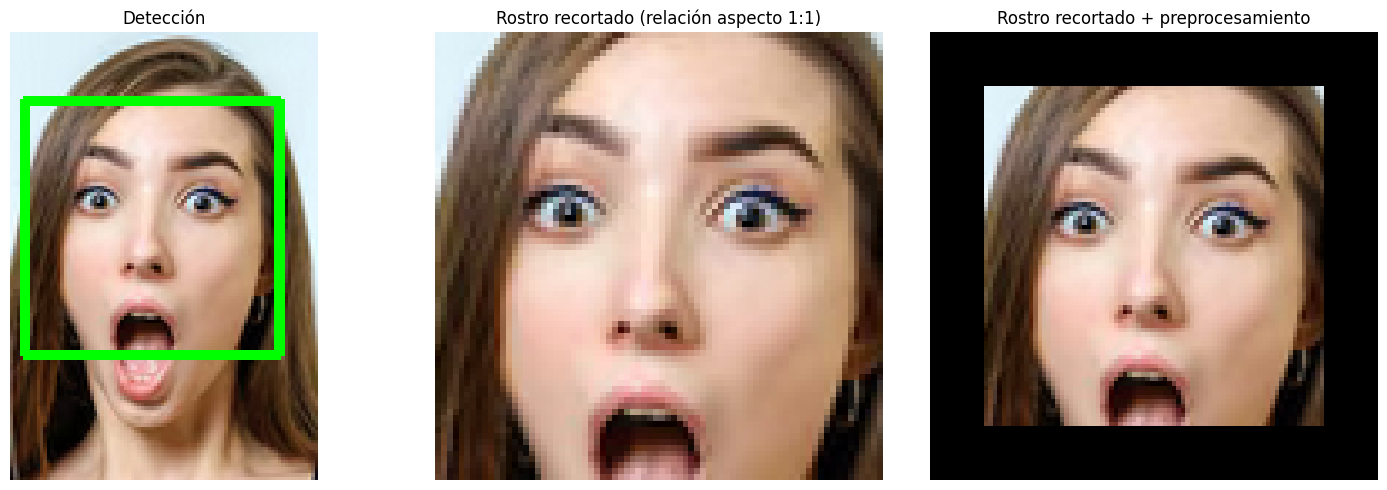

tensor([[-9.0092, -8.1162, -1.3619,  0.1161, -2.3200,  5.2869, -0.4905]])
sorpresa


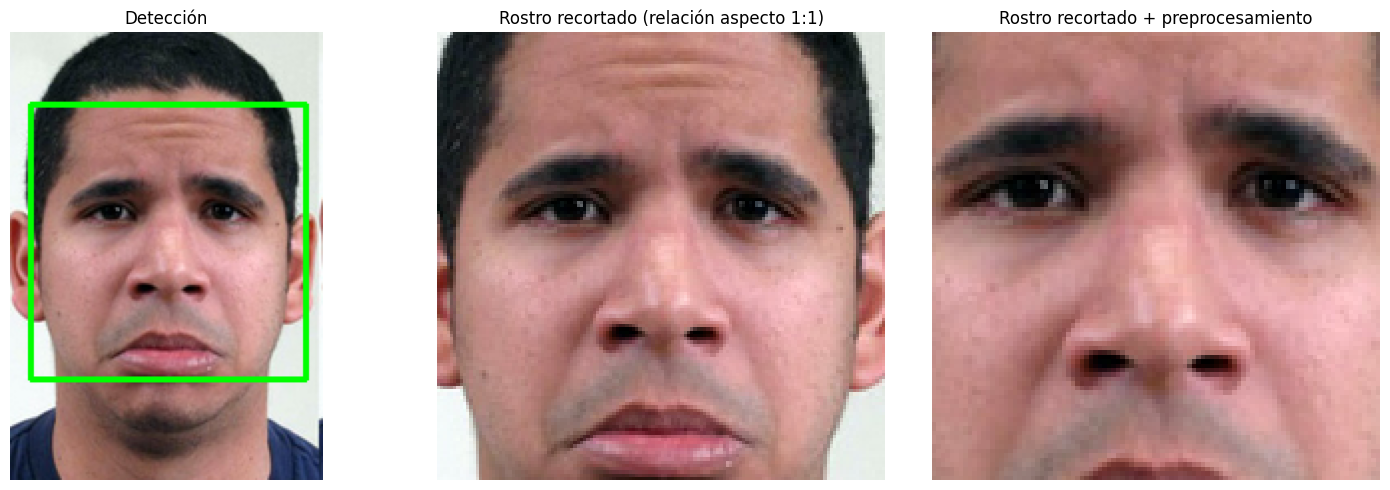

tensor([[ 1.5409, -4.4257, -9.3029, -2.7704, -1.4592, -3.5687, -0.1024]])
alegria


In [74]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

for i, image_path in enumerate([
     "my_dataset/alegria/alegria.png",
     "my_dataset/alegria/alegria2.png",
     "my_dataset/disgusto/disgusto.png",
     "my_dataset/disgusto/disgusto2.png",
     "my_dataset/enojo/enojo.png",
     "my_dataset/miedo/miedo.png",
     "my_dataset/seriedad/seriedad.png",
     "my_dataset/sorpresa/sorpresa.png",
     "my_dataset/sorpresa/sorpresa2.png",
     "my_dataset/tristeza/tristeza.png",
]):
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=6)

    image_with_box = image.copy()
    for (x, y, w, h) in faces:
        cv2.rectangle(image_with_box, (x, y), (x + w, y + h), (0, 255, 0), 2)

    cropped_face_rgb = None
    if len(faces) > 0:
        (x, y, w, h) = faces[0]
        center_x, center_y = x + w // 2, y + h // 2
        side = max(w, h)
        half_side = side // 2

        x1 = max(center_x - half_side, 0)
        y1 = max(center_y - half_side, 0)
        x2 = min(center_x + half_side, image.shape[1])
        y2 = min(center_y + half_side, image.shape[0])

        cropped_face = image[y1:y2, x1:x2]
        cropped_face_rgb = cv2.cvtColor(cropped_face, cv2.COLOR_BGR2RGB)

    image_with_box_rgb = cv2.cvtColor(image_with_box, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(image_with_box_rgb)
    ax[0].set_title("Detección")
    ax[0].axis('off')

    if cropped_face_rgb is not None:
        ax[1].imshow(cropped_face_rgb)
        ax[1].set_title("Rostro recortado (relación aspecto 1:1)")
        ax[1].axis('off')
    else:
        ax[1].text(0.5, 0.5, 'No se detectó rostro', horizontalalignment='center', verticalalignment='center')
        ax[1].axis('off')

    X_cropped = composition(Image.fromarray(cropped_face_rgb))
    ax[2].imshow(torch.clamp(X_cropped, 0, 1).permute(1,2,0).numpy())
    ax[2].set_title('Rostro recortado + preprocesamiento')
    ax[2].axis('off')
    plt.tight_layout()
    plt.show()

    X_cropped = X_cropped.reshape(1,3,100,100).to(device)

    model.eval()
    with torch.no_grad():
        yhat = model(X_cropped).cpu()
        predicted = emociones[yhat.argmax()]
        print(yhat)
        print(predicted)
        summary[i].append(predicted)


A continuación podemos ver agregado al resumen anterior la columna con el preproceso propuesto.

Se observa que ahora si se tiene una sobrepredicción de alegría, más en línea con lo que se observaba en la matriz de confusión. Esto puede indicarnos que las imágenes originalmente utilizadas para entrenamiento y testeo vienen de algún modelo de preprocesamiento similar al utilizado aquí.

En este caso se tiene un acierto de 3/10, pero que en el caso anterior.

In [75]:
print('Resumen:')
print(pd.DataFrame(summary, columns=['Real', 'Predicho', 'Predicho con preproceso']))

Resumen:
       Real  Predicho Predicho con preproceso
0   alegria  tristeza                   miedo
1   alegria     enojo                tristeza
2  disgusto  seriedad                   enojo
3  disgusto     enojo                tristeza
4     enojo     miedo                   miedo
5     miedo  sorpresa                sorpresa
6  seriedad     enojo                   miedo
7  sorpresa  sorpresa                sorpresa
8  sorpresa  sorpresa                sorpresa
9  tristeza  sorpresa                 alegria


**Conclusiones**

Se desarrolló una red convolucional para detección de emociones en función de las expresiones faciales. Se obtuvieron resultados aceptables de precisión en entrenamiento y con el set de testeo provisto, pero al utilizar nuevas imágenes se obtuvieron resultados bastante pobres. 

Aún así, no se debería descartar el modelo, si no que el mayor punto de mejora está en el set de imagenes a utilizar en entrenamiento y el preprocesamiento que tienen. En particular, si se aplicó un reconocimiento de dónde está la cara de la persona en la imagen para luego recortar, ya que es clave que se tenga toda la cara disponible para capturar posibles tendencias.